# Biomarker Comparison: Cognitive Stress vs Physical Stress

**Goal**: Determine if we can distinguish **cognitive stress** from **physical stress** (aerobic/anaerobic exercise) using wearable biosignals.

**Key Question**: *Can we really distinguish cognitive stress apart from aerobic/anaerobic?*

### WHY it matters
- All three conditions (cognitive stress, aerobic, anaerobic) elevate HR and movement
- If biomarkers overlap significantly, a stress classifier trained on lab data may misclassify exercise as stress

#### STEPS
1. Combine feature data from all three WISE protocols
2. Label active periods as: COGNITIVE, AEROBIC, ANAEROBIC
3. Statistical comparison (ANOVA + post-hoc tests)
4. Visualization of feature distributions
5. Build a 3-class Activity Classifier

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

---
## 1. Load Data from All Three Protocols

Use the same helper functions from the existing notebooks.

In [ ]:
# Helper functions (from existing notebooks)
def create_df_array(dataframe):
    return dataframe.values.flatten()

def time_abs_(UTC_array):
    new_array = []
    start_time = datetime.datetime.strptime(UTC_array[0], '%Y-%m-%d %H:%M:%S')
    for utc in UTC_array:
        current_time = datetime.datetime.strptime(utc, '%Y-%m-%d %H:%M:%S')
        seconds_elapsed = (current_time - start_time).total_seconds()
        new_array.append(int(seconds_elapsed))
    return new_array

def moving_average(acc_data):
    avg = 0
    prevX, prevY, prevZ = 0, 0, 0
    results = []
    for i in range(0, len(acc_data), 32):
        sum_ = 0
        buffX = acc_data[i:i+32, 0]
        buffY = acc_data[i:i+32, 1]
        buffZ = acc_data[i:i+32, 2]
        for j in range(len(buffX)):
            sum_ += max(abs(buffX[j] - prevX), abs(buffY[j] - prevY), abs(buffZ[j] - prevZ))
            prevX, prevY, prevZ = buffX[j], buffY[j], buffZ[j]
        avg = avg * 0.9 + (sum_ / 32) * 0.1
        results.append(avg)
    return results

def read_signals(main_folder):
    signal_dict = {}
    time_dict = {}
    fs_dict = {}
    
    subfolders = next(os.walk(main_folder))[1]
    
    utc_start_dict = {}
    for folder_name in subfolders:
        csv_path = f'{main_folder}/{folder_name}/EDA.csv'
        df = pd.read_csv(csv_path)
        utc_start_dict[folder_name] = df.columns.tolist()
    
    for folder_name in subfolders:
        folder_path = os.path.join(main_folder, folder_name)
        files = os.listdir(folder_path)
        
        signals = {}
        time_line = {}
        fs_signal = {}
        
        desired_files = ['EDA.csv', 'BVP.csv', 'HR.csv', 'TEMP.csv', 'tags.csv', 'ACC.csv', 'IBI.csv']
        
        for file_name in files:
            if file_name not in desired_files:
                continue
            
            file_path = os.path.join(folder_path, file_name)
            signal_name = file_name.replace('.csv', '')
            
            if file_name == 'tags.csv':
                try:
                    df = pd.read_csv(file_path, header=None)
                    tags_vector = create_df_array(df)
                    tags_UTC_vector = np.insert(tags_vector, 0, utc_start_dict[folder_name])
                    signal_array = time_abs_(tags_UTC_vector)
                except pd.errors.EmptyDataError:
                    signal_array = []
            elif file_name == 'IBI.csv':
                df = pd.read_csv(file_path)
                signal_array = df.values
                fs_signal['IBI'] = 'variable'
            else:
                df = pd.read_csv(file_path)
                fs = int(df.iloc[0, 0])
                signal_array = df.iloc[1:].values
                time_array = np.linspace(0, len(signal_array)/fs, len(signal_array))
                time_line[signal_name] = time_array
                fs_signal[signal_name] = fs
            
            signals[signal_name] = signal_array
        
        signal_dict[folder_name] = signals
        time_dict[folder_name] = time_line
        fs_dict[folder_name] = fs_signal
    
    return signal_dict, time_dict, fs_dict

In [40]:
# HRV calculation
def calculate_hrv(ibi_data, start_time, end_time):
    if len(ibi_data) == 0:
        return {'SDNN': np.nan, 'RMSSD': np.nan}
    timestamps = ibi_data[:, 0]
    ibi_values = ibi_data[:, 1]
    mask = (timestamps >= start_time) & (timestamps <= end_time)
    segment_ibi = ibi_values[mask]
    
    if len(segment_ibi) < 2:
        return {'SDNN': np.nan, 'RMSSD': np.nan}
    
    sdnn = np.std(segment_ibi)
    rmssd = np.sqrt(np.mean(np.diff(segment_ibi)**2))
    return {'SDNN': sdnn, 'RMSSD': rmssd}

# Feature extraction
def extract_segment_features(subject, segment, signals, fs_dict):
    features = {
        'subject': subject,
        'label': segment['label'],
        'phase': segment['phase'],
        'duration': segment['end'] - segment['start']
    }
    
    start_t, end_t = segment['start'], segment['end']
    
    # HRV
    if 'IBI' in signals and len(signals['IBI']) > 0:
        hrv = calculate_hrv(signals['IBI'], start_t, end_t)
        features.update(hrv)
    else:
        features.update({'SDNN': np.nan, 'RMSSD': np.nan})
    
    # EDA
    if 'EDA' in signals:
        fs = fs_dict[subject]['EDA']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        eda = signals['EDA'][idx_start:idx_end].flatten()
        if len(eda) > 0:
            features['EDA_mean'] = np.mean(eda)
            features['EDA_std'] = np.std(eda)
    
    # HR
    if 'HR' in signals:
        fs = fs_dict[subject]['HR']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        hr = signals['HR'][idx_start:idx_end].flatten()
        if len(hr) > 0:
            features['HR_mean'] = np.mean(hr)
            features['HR_std'] = np.std(hr)
    
    # Temperature
    if 'TEMP' in signals:
        fs = fs_dict[subject]['TEMP']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        temp = signals['TEMP'][idx_start:idx_end].flatten()
        if len(temp) > 0:
            features['TEMP_mean'] = np.mean(temp)
            features['TEMP_std'] = np.std(temp)
    
    # Accelerometer
    if 'ACC' in signals:
        fs = fs_dict[subject]['ACC']
        idx_start, idx_end = int(start_t * fs), int(end_t * fs)
        acc = signals['ACC'][idx_start:idx_end]
        if len(acc) > 0:
            acc_filtered = moving_average(acc)
            features['ACC_mean'] = np.mean(acc_filtered)
            features['ACC_std'] = np.std(acc_filtered)
    
    return features

## Define paths to Data

In [41]:
STRESS_PATH = '22subjects/STRESS'
AEROBIC_PATH = '22subjects/AEROBIC'
ANAEROBIC_PATH = '22subjects/ANAEROBIC'

In [52]:
# Load all three datasets
print("Loading STRESS protocol data...")
stress_signals, stress_time, stress_fs = read_signals(STRESS_PATH)

print("Loading AEROBIC protocol data...")
aerobic_signals, aerobic_time, aerobic_fs = read_signals(AEROBIC_PATH)

print("Loading ANAEROBIC protocol data...")
anaerobic_signals, anaerobic_time, anaerobic_fs = read_signals(ANAEROBIC_PATH)

print(f"  STRESS: {len(stress_signals)} subjects")
print(f"  AEROBIC: {len(aerobic_signals)} subjects")
print(f"  ANAEROBIC: {len(anaerobic_signals)} subjects")

Loading STRESS protocol data...
Loading AEROBIC protocol data...
Loading ANAEROBIC protocol data...
  STRESS: 22 subjects
  AEROBIC: 22 subjects
  ANAEROBIC: 22 subjects


---
## 2. Segment Data by Protocol

For this comparison, we only take the **ACTIVE** periods:
- **COGNITIVE**: STRESS segments from the stress protocol (TMCT, Stroop, Opinion, Subtract)
- **AEROBIC**: EXERCISE segments from aerobic protocol (cycling phases)
- **ANAEROBIC**: EXERCISE segments from anaerobic protocol (sprint phases)

In [53]:
# Segmentation functions for each protocol
# VERIFIED against WISE_Stress_EDA_Model.ipynb and Wearable_Dataset.ipynb NOTEBOOKS

def get_stress_segments(subject_id, tags):
    """Get STRESS (cognitive task) segments only.
    
    VERIFIED: Matches WISE_Stress_EDA_Model.ipynb segmentation.
    - V1 (S subjects): 14 tags, requires >= 13
    - V2 (f subjects): 10 tags, requires >= 10
    """
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol (males, with Stroop)
        if len(tags) >= 13:
            segments.append({'start': tags[3], 'end': tags[4], 'label': 'COGNITIVE', 'phase': 'Stroop'})
            segments.append({'start': tags[5], 'end': tags[6], 'label': 'COGNITIVE', 'phase': 'TMCT'})
            segments.append({'start': tags[7], 'end': tags[8], 'label': 'COGNITIVE', 'phase': 'Real Opinion'})
            segments.append({'start': tags[9], 'end': tags[10], 'label': 'COGNITIVE', 'phase': 'Opposite Opinion'})
            segments.append({'start': tags[11], 'end': tags[12], 'label': 'COGNITIVE', 'phase': 'Subtract'})
    else:  # V2 protocol (females, no Stroop)
        if len(tags) >= 10:
            segments.append({'start': tags[2], 'end': tags[3], 'label': 'COGNITIVE', 'phase': 'TMCT'})
            segments.append({'start': tags[4], 'end': tags[5], 'label': 'COGNITIVE', 'phase': 'Real Opinion'})
            segments.append({'start': tags[6], 'end': tags[7], 'label': 'COGNITIVE', 'phase': 'Opposite Opinion'})
            segments.append({'start': tags[8], 'end': tags[9], 'label': 'COGNITIVE', 'phase': 'Subtract'})
    
    return segments

def get_aerobic_segments(subject_id, tags):
    """Get EXERCISE segments from aerobic protocol.
    
    V1 (S subjects): 13 tags, 10 cycling phases at 60-110 rpm (~120-180s each)
    V2 (f subjects): 9 tags, 5 cycling phases including long 85 rpm phase (~675s)
    
    CORRECTED: V2 phase labels now accurately reflect RPM based on duration:
    - Short phases (~90-200s): 70, 75, 80, 90/95 rpm
    - Long phase (~675s): 85 rpm
    """
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol - consistent structure
        if len(tags) >= 12:
            # V1: 10 exercise phases from 60-110 rpm
            rpm_phases = ['60 rpm', '70 rpm', '75 rpm', '80 rpm', '85 rpm', 
                         '90 rpm', '95 rpm', '100 rpm', '105 rpm', '110 rpm']
            for i, phase_name in enumerate(rpm_phases):
                if i + 2 < len(tags):
                    segments.append({'start': tags[i + 1], 'end': tags[i + 2], 
                                   'label': 'AEROBIC', 'phase': phase_name})
    else:  # V2 protocol - variable structure, use duration-based labeling
        if len(tags) >= 8:
            # V2 exercise phases: identify by duration
            # - Short phases (70, 75, 80, 90/95 rpm): ~90-200s
            # - Long phase (85 rpm): ~675s (11:15 per protocol)
            phase_labels = []
            for i in range(len(tags)-1):
                duration = tags[i+1] - tags[i]
                if 60 <= duration <= 250:
                    phase_labels.append(('short', i))
                elif 500 <= duration <= 800:
                    phase_labels.append(('long_85rpm', i))
            
            # Assign RPM labels based on order
            short_rpms = ['70 rpm', '75 rpm', '80 rpm', '90/95 rpm']
            short_idx = 0
            
            for phase_type, tag_idx in phase_labels:
                if phase_type == 'long_85rpm':
                    segments.append({'start': tags[tag_idx], 'end': tags[tag_idx+1],
                                   'label': 'AEROBIC', 'phase': '85 rpm (sustained)'})
                elif phase_type == 'short' and short_idx < len(short_rpms):
                    segments.append({'start': tags[tag_idx], 'end': tags[tag_idx+1],
                                   'label': 'AEROBIC', 'phase': short_rpms[short_idx]})
                    short_idx += 1
    
    return segments

def get_anaerobic_segments(subject_id, tags):
    """Get EXERCISE (sprint) segments from anaerobic protocol.
    
    VERIFIED: Sprint durations are 28-40s.
    - V1 (S subjects): 8 tags, 3 sprints
    - V2 (f subjects): 12 tags, 4 sprints
    """
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol
        if len(tags) >= 7:
            segments.append({'start': tags[1], 'end': tags[2], 'label': 'ANAEROBIC', 'phase': 'Sprint 1'})
            segments.append({'start': tags[3], 'end': tags[4], 'label': 'ANAEROBIC', 'phase': 'Sprint 2'})
            segments.append({'start': tags[5], 'end': tags[6], 'label': 'ANAEROBIC', 'phase': 'Sprint 3'})
    else:  # V2 protocol
        if len(tags) >= 11:
            segments.append({'start': tags[2], 'end': tags[3], 'label': 'ANAEROBIC', 'phase': 'Sprint 1'})
            segments.append({'start': tags[4], 'end': tags[5], 'label': 'ANAEROBIC', 'phase': 'Sprint 2'})
            segments.append({'start': tags[6], 'end': tags[7], 'label': 'ANAEROBIC', 'phase': 'Sprint 3'})
            segments.append({'start': tags[8], 'end': tags[9], 'label': 'ANAEROBIC', 'phase': 'Sprint 4'})
    
    return segments

In [ ]:
# Extract features from all three protocols
all_features = []

# COGNITIVE (from STRESS protocol)
for subject in stress_signals.keys():
    tags = stress_signals[subject]['tags']
    if len(tags) > 0:
        segments = get_stress_segments(subject, tags)
        for segment in segments:
            feat = extract_segment_features(subject, segment, stress_signals[subject], stress_fs)
            feat['activity_type'] = 'COGNITIVE'
            all_features.append(feat)

# AEROBIC
for subject in aerobic_signals.keys():
    tags = aerobic_signals[subject]['tags']
    if len(tags) > 0:
        segments = get_aerobic_segments(subject, tags)
        for segment in segments:
            feat = extract_segment_features(subject, segment, aerobic_signals[subject], aerobic_fs)
            feat['activity_type'] = 'AEROBIC'
            all_features.append(feat)

# ANAEROBIC
for subject in anaerobic_signals.keys():
    tags = anaerobic_signals[subject]['tags']
    if len(tags) > 0:
        segments = get_anaerobic_segments(subject, tags)
        for segment in segments:
            feat = extract_segment_features(subject, segment, anaerobic_signals[subject], anaerobic_fs)
            feat['activity_type'] = 'ANAEROBIC'
            all_features.append(feat)

# Create DataFrame
df_combined = pd.DataFrame(all_features)

print(f"\n{'='*60}")
print("COMBINED DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total segments: {len(df_combined)}")
print(f"\nBy Activity Type:")
print(df_combined['activity_type'].value_counts())
print(f"\nFeatures: {[c for c in df_combined.columns if c not in ['subject', 'label', 'phase', 'duration', 'activity_type']]}")

Extracting COGNITIVE features...
Extracting AEROBIC features...
Extracting ANAEROBIC features...

COMBINED DATASET SUMMARY
Total segments: 341

By Activity Type:
activity_type
AEROBIC      165
COGNITIVE     98
ANAEROBIC     78
Name: count, dtype: int64

Features: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']


---
## 3. Statistical Comparison: ANOVA + Post-hoc Tests

**Key Question**: Which biomarkers significantly differ across the three activity types?

In [45]:
# Define features to compare
biomarkers = ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 
              'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']

# Filter to only include features that exist
biomarkers = [b for b in biomarkers if b in df_combined.columns]

print(f"{'='*80}")
print("ANOVA: Comparing Biomarkers Across COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"{'='*80}")
print(f"{'Biomarker':<12} {'F-stat':<10} {'p-value':<12} {'Sig':<5} {'COGNITIVE':<12} {'AEROBIC':<12} {'ANAEROBIC':<12}")
print("-" * 80)

anova_results = []

for bio in biomarkers:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    if len(cognitive) > 2 and len(aerobic) > 2 and len(anaerobic) > 2:
        # One-way ANOVA
        f_stat, p_val = f_oneway(cognitive, aerobic, anaerobic)
        
        # Significance
        if p_val < 0.001:
            sig = "***"
        elif p_val < 0.01:
            sig = "**"
        elif p_val < 0.05:
            sig = "*"
        else:
            sig = "ns"
        
        print(f"{bio:<12} {f_stat:<10.2f} {p_val:<12.6f} {sig:<5} {cognitive.mean():<12.2f} {aerobic.mean():<12.2f} {anaerobic.mean():<12.2f}")
        
        anova_results.append({
            'biomarker': bio,
            'f_stat': f_stat,
            'p_value': p_val,
            'significant': sig != 'ns',
            'cognitive_mean': cognitive.mean(),
            'aerobic_mean': aerobic.mean(),
            'anaerobic_mean': anaerobic.mean()
        })

print("\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant")

df_anova = pd.DataFrame(anova_results)

ANOVA: Comparing Biomarkers Across COGNITIVE vs AEROBIC vs ANAEROBIC
Biomarker    F-stat     p-value      Sig   COGNITIVE    AEROBIC      ANAEROBIC   
--------------------------------------------------------------------------------
SDNN         2.73       0.067339     ns    0.06         0.06         0.04        
RMSSD        1.61       0.200900     ns    0.06         0.07         0.06        
EDA_mean     3.45       0.032721     *     5.08         8.16         7.48        
EDA_std      6.50       0.001698     **    0.37         0.98         0.94        
HR_mean      24.12      0.000000     ***   81.62        99.21        101.23      
HR_std       11.49      0.000015     ***   2.47         4.72         3.25        
TEMP_mean    3.40       0.034636     *     32.79        32.10        36.90       
TEMP_std     0.83       0.438860     ns    0.04         0.61         0.14        
ACC_mean     229.27     0.000000     ***   1.48         5.04         10.58       
ACC_std      210.32     0.0000

In [46]:
# Post-hoc pairwise comparisons (for significant features)
from scipy.stats import ttest_ind

print(f"\n{'='*80}")
print("POST-HOC PAIRWISE COMPARISONS (Welch's t-test)")
print(f"{'='*80}")

significant_biomarkers = df_anova[df_anova['significant']]['biomarker'].tolist()

for bio in significant_biomarkers:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    print(f"\n{bio}:")
    
    # Cognitive vs Aerobic
    t1, p1 = ttest_ind(cognitive, aerobic, equal_var=False)
    sig1 = "***" if p1 < 0.001 else "**" if p1 < 0.01 else "*" if p1 < 0.05 else "ns"
    print(f"  COGNITIVE vs AEROBIC:   p={p1:.6f} {sig1}")
    
    # Cognitive vs Anaerobic
    t2, p2 = ttest_ind(cognitive, anaerobic, equal_var=False)
    sig2 = "***" if p2 < 0.001 else "**" if p2 < 0.01 else "*" if p2 < 0.05 else "ns"
    print(f"  COGNITIVE vs ANAEROBIC: p={p2:.6f} {sig2}")
    
    # Aerobic vs Anaerobic
    t3, p3 = ttest_ind(aerobic, anaerobic, equal_var=False)
    sig3 = "***" if p3 < 0.001 else "**" if p3 < 0.01 else "*" if p3 < 0.05 else "ns"
    print(f"  AEROBIC vs ANAEROBIC:   p={p3:.6f} {sig3}")


POST-HOC PAIRWISE COMPARISONS (Welch's t-test)

EDA_mean:
  COGNITIVE vs AEROBIC:   p=0.006261 **
  COGNITIVE vs ANAEROBIC: p=0.057653 ns
  AEROBIC vs ANAEROBIC:   p=0.594078 ns

EDA_std:
  COGNITIVE vs AEROBIC:   p=0.000053 ***
  COGNITIVE vs ANAEROBIC: p=0.000278 ***
  AEROBIC vs ANAEROBIC:   p=0.842452 ns

HR_mean:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000000 ***
  AEROBIC vs ANAEROBIC:   p=0.557878 ns

HR_std:
  COGNITIVE vs AEROBIC:   p=0.000001 ***
  COGNITIVE vs ANAEROBIC: p=0.023111 *
  AEROBIC vs ANAEROBIC:   p=0.002144 **

TEMP_mean:
  COGNITIVE vs AEROBIC:   p=0.030347 *
  COGNITIVE vs ANAEROBIC: p=0.201870 ns
  AEROBIC vs ANAEROBIC:   p=0.137901 ns

ACC_mean:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000000 ***
  AEROBIC vs ANAEROBIC:   p=0.000000 ***

ACC_std:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000000 ***
  AEROBIC vs ANAEROBIC:   p=0.000000 ***


---
## 4. Visualizations

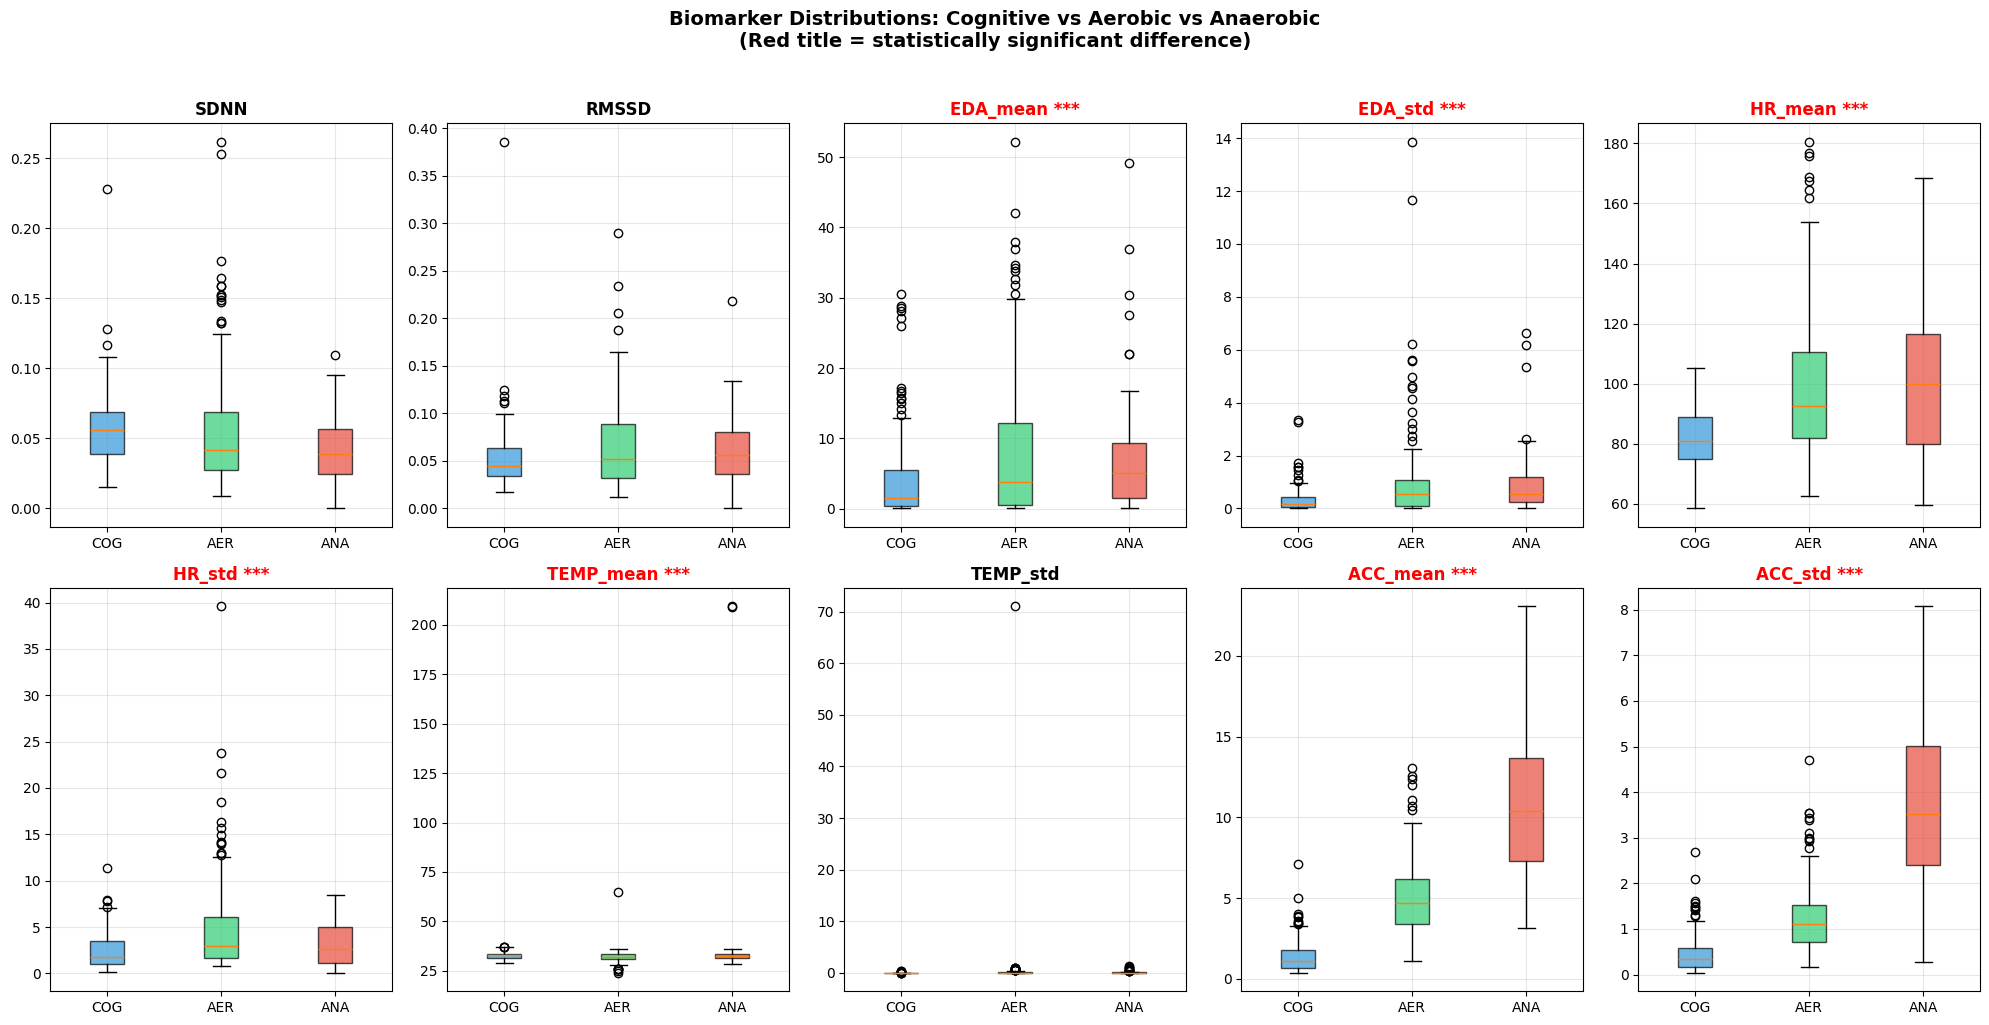

In [47]:
# Box plots comparing distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

colors = {'COGNITIVE': '#3498db', 'AEROBIC': '#2ecc71', 'ANAEROBIC': '#e74c3c'}

for i, bio in enumerate(biomarkers):
    ax = axes[i]
    
    # Create box plot data
    data_to_plot = []
    labels = []
    for activity in ['COGNITIVE', 'AEROBIC', 'ANAEROBIC']:
        vals = df_combined[df_combined['activity_type'] == activity][bio].dropna()
        data_to_plot.append(vals)
        labels.append(activity)
    
    bp = ax.boxplot(data_to_plot, labels=['COG', 'AER', 'ANA'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], [colors['COGNITIVE'], colors['AEROBIC'], colors['ANAEROBIC']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(bio, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add significance marker if ANOVA was significant
    if bio in significant_biomarkers:
        ax.set_title(f"{bio} ***", fontsize=12, fontweight='bold', color='red')

# Hide empty subplots
for j in range(len(biomarkers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Biomarker Distributions: Cognitive vs Aerobic vs Anaerobic\n(Red title = statistically significant difference)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

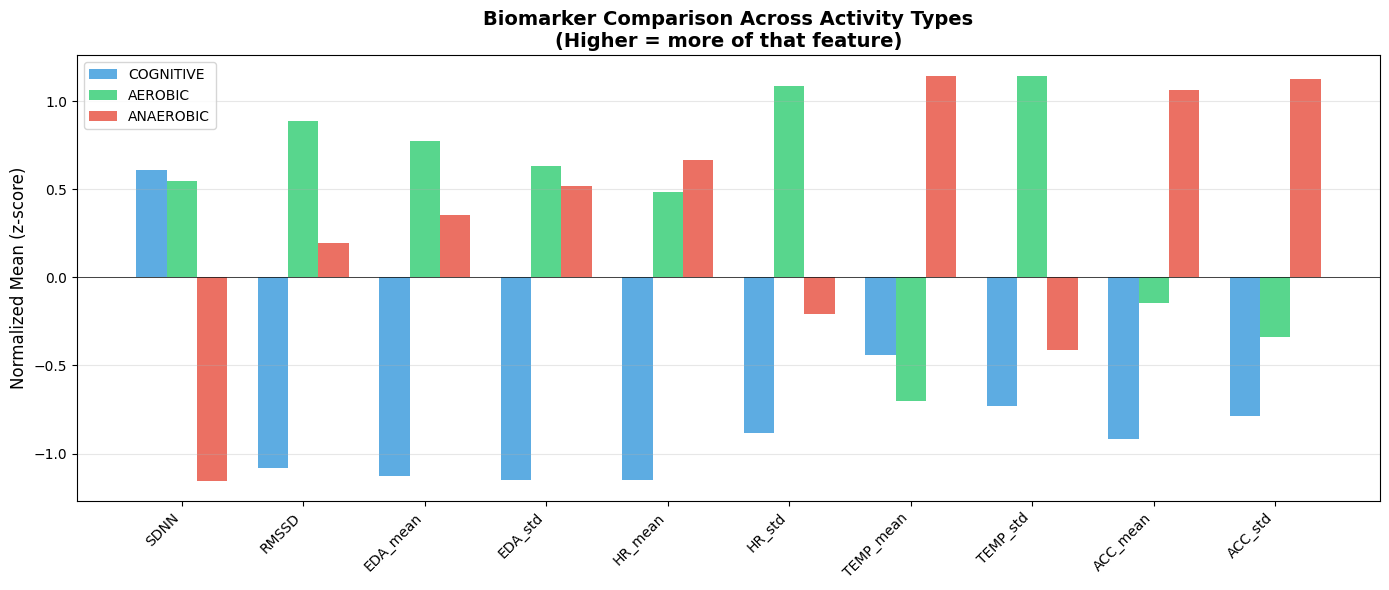

In [48]:
# Mean comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Normalize means for visualization (z-score across activities)
means_df = df_combined.groupby('activity_type')[biomarkers].mean()
means_normalized = (means_df - means_df.mean()) / means_df.std()

x = np.arange(len(biomarkers))
width = 0.25

bars1 = ax.bar(x - width, means_normalized.loc['COGNITIVE'], width, label='COGNITIVE', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, means_normalized.loc['AEROBIC'], width, label='AEROBIC', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, means_normalized.loc['ANAEROBIC'], width, label='ANAEROBIC', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Normalized Mean (z-score)', fontsize=12)
ax.set_title('Biomarker Comparison Across Activity Types\n(Higher = more of that feature)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(biomarkers, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

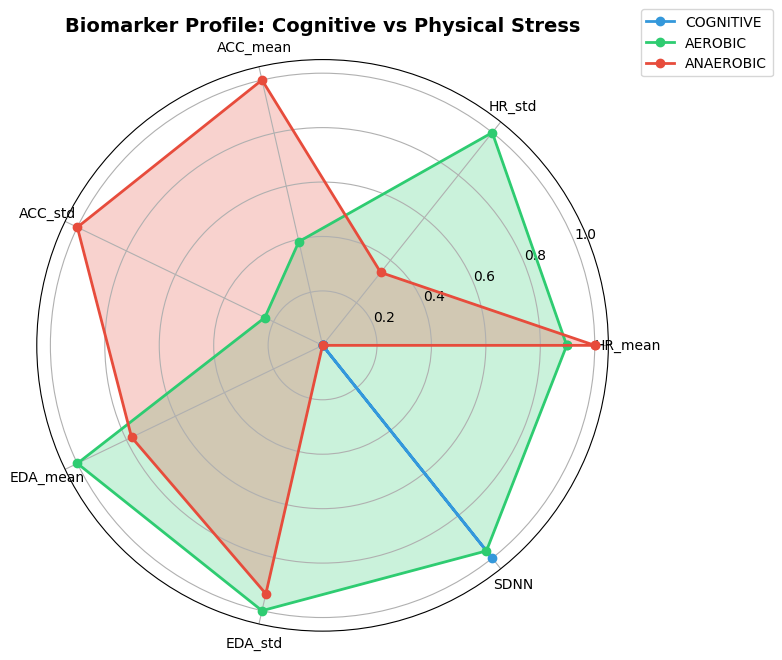

In [49]:
# Radar/Spider chart for each activity type
from math import pi

# Select key biomarkers for radar chart
radar_features = ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std', 'EDA_mean', 'EDA_std', 'SDNN']
radar_features = [f for f in radar_features if f in df_combined.columns]

# Normalize to 0-1 scale for radar
means = df_combined.groupby('activity_type')[radar_features].mean()
means_norm = (means - means.min()) / (means.max() - means.min())

# Number of variables
N = len(radar_features)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # complete the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = {'COGNITIVE': '#3498db', 'AEROBIC': '#2ecc71', 'ANAEROBIC': '#e74c3c'}

for activity in ['COGNITIVE', 'AEROBIC', 'ANAEROBIC']:
    values = means_norm.loc[activity].values.tolist()
    values += values[:1]  # complete the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=activity, color=colors[activity])
    ax.fill(angles, values, alpha=0.25, color=colors[activity])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title('Biomarker Profile: Cognitive vs Physical Stress', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

---
## 5. Start to build a 3-Class Activity Classifier

**Goal**: Can we classify segments into COGNITIVE, AEROBIC, or ANAEROBIC based on biomarkers alone?

In [54]:
#classification for activity type based on biomarkers
feature_cols = [c for c in biomarkers if c in df_combined.columns]

X = df_combined[feature_cols]
y = df_combined['activity_type']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features used: {feature_cols}")
print(f"Classes: {le.classes_}")
print(f"Class distribution: {dict(zip(le.classes_, np.bincount(y_encoded)))}")

Features used: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']
Classes: ['AEROBIC' 'ANAEROBIC' 'COGNITIVE']
Class distribution: {'AEROBIC': np.int64(165), 'ANAEROBIC': np.int64(78), 'COGNITIVE': np.int64(98)}


In [55]:
# Test multiple classifiers
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42)
}


print("3-CLASS ACTIVITY CLASSIFIER COMPARISON")
print(f"{'='*60}")
print(f"Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"{'='*60}\n")

results = []

for clf_name, clf in classifiers.items():
    pipeline = make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler(),
        clf
    )
    
    cv_scores = cross_val_score(pipeline, X, y_encoded, cv=5, scoring='accuracy')
    
    print(f"{clf_name:20}: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    
    results.append({
        'Classifier': clf_name,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

df_results = pd.DataFrame(results)
best = df_results.loc[df_results['CV Accuracy'].idxmax()]
print(f"\nBEST: {best['Classifier']} with {best['CV Accuracy']:.1%} accuracy")

3-CLASS ACTIVITY CLASSIFIER COMPARISON
Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC

Random Forest       : 0.842 (+/- 0.100)
Gradient Boosting   : 0.821 (+/- 0.107)
AdaBoost            : 0.786 (+/- 0.076)
SVM (RBF)           : 0.769 (+/- 0.209)

BEST: Random Forest with 84.2% accuracy


Classification Report:

              precision    recall  f1-score   support

     AEROBIC       0.88      0.91      0.90        33
   ANAEROBIC       0.92      0.75      0.83        16
   COGNITIVE       0.86      0.95      0.90        20

    accuracy                           0.88        69
   macro avg       0.89      0.87      0.88        69
weighted avg       0.89      0.88      0.88        69



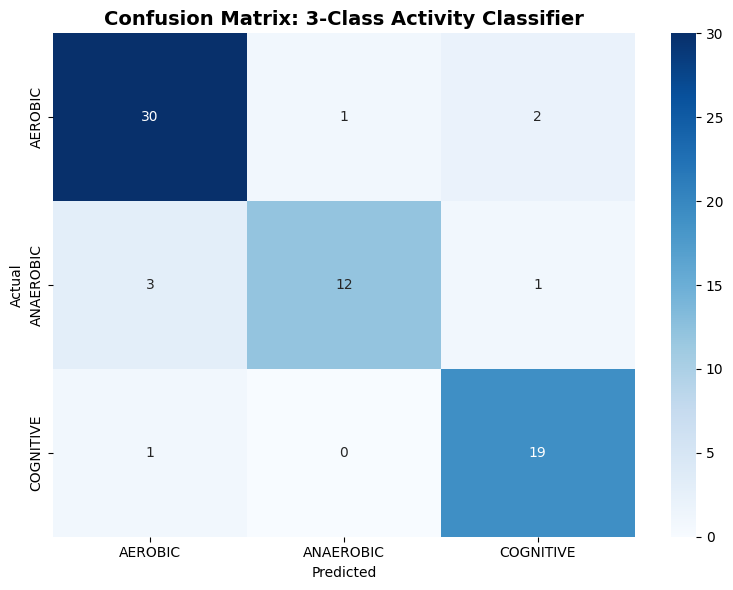

In [56]:
# Train best model and show confusion matrix
from sklearn.model_selection import train_test_split

# Use Random Forest
best_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: 3-Class Activity Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

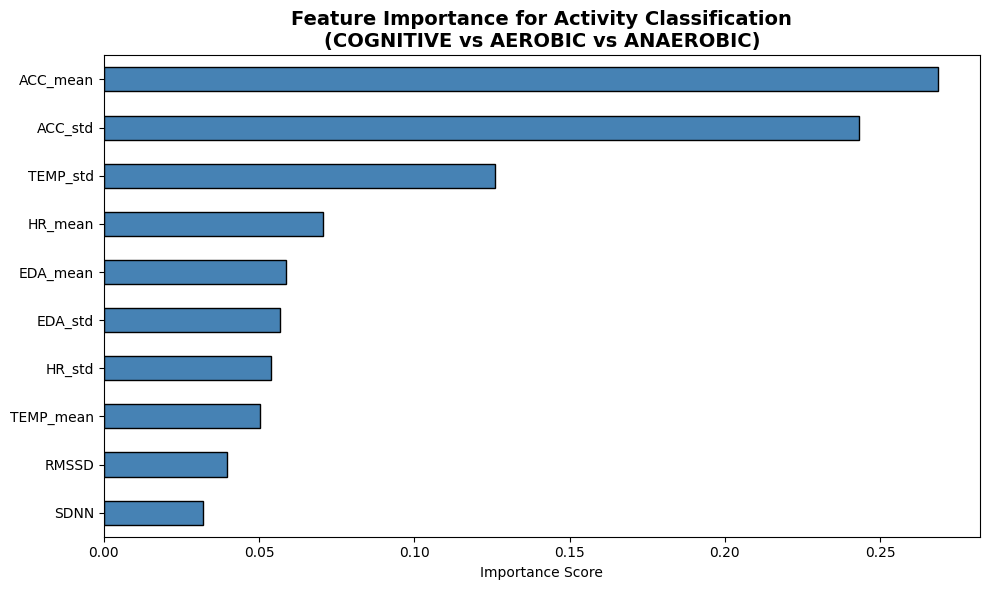


Top 5 Most Important Features for Activity Classification:
  ACC_mean: 0.269
  ACC_std: 0.243
  TEMP_std: 0.126
  HR_mean: 0.071
  EDA_mean: 0.059


In [57]:
# Feature importance for activity classification
rf_model = best_pipeline.named_steps['randomforestclassifier']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance for Activity Classification\n(COGNITIVE vs AEROBIC vs ANAEROBIC)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features for Activity Classification:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {imp:.3f}")

---
## 6. Summary of findings

In [59]:
print("BIOMARKER COMPARISON SUMMARY")
print("="*70)

print("\n1. STATISTICALLY SIGNIFICANT DIFFERENCES (ANOVA p < 0.05):")
for _, row in df_anova[df_anova['significant']].iterrows():
    print(f"   - {row['biomarker']}: F={row['f_stat']:.2f}, p={row['p_value']:.6f}")

print("\n2. KEY DISTINGUISHING FEATURES:")
print("   Features that best separate COGNITIVE from PHYSICAL stress:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"   - {feat} (importance: {imp:.3f})")

print(f"\n3. ACTIVITY CLASSIFIER PERFORMANCE:")
print(f"   Best model: {best['Classifier']}")
print(f"   Accuracy: {best['CV Accuracy']:.1%}")

BIOMARKER COMPARISON SUMMARY

1. STATISTICALLY SIGNIFICANT DIFFERENCES (ANOVA p < 0.05):
   - EDA_mean: F=3.45, p=0.032721
   - EDA_std: F=6.50, p=0.001698
   - HR_mean: F=24.12, p=0.000000
   - HR_std: F=11.49, p=0.000015
   - TEMP_mean: F=3.40, p=0.034636
   - ACC_mean: F=229.27, p=0.000000
   - ACC_std: F=210.32, p=0.000000

2. KEY DISTINGUISHING FEATURES:
   Features that best separate COGNITIVE from PHYSICAL stress:
   - ACC_mean (importance: 0.269)
   - ACC_std (importance: 0.243)
   - TEMP_std (importance: 0.126)

3. ACTIVITY CLASSIFIER PERFORMANCE:
   Best model: Random Forest
   Accuracy: 84.2%


# Notes for next steps